## How are in-demand skills trending for Data Analysts?
Methology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Data - only data for 2023
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

# Loading Data - 2023, 2024, 2025 and first half of 2026:
df = pd.read_csv(r"C:\Users\Nikola S\Desktop\Luke B\job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Group the Skills by Month
Select only those job postings that are for Data Analysts and the job country is the United States. Then extract the month from each job's posting date to see when jobs are listed. Next, converts a column that lists skills into a usable list format. Finally, it rearranges the data so that each skill from the list gets its own row.

In [5]:
df = df[df["job_posted_date"].dt.year == 2025]

df_DA_USA = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()
df_DA_USA["job_posted_month_no"] = df_DA_USA["job_posted_date"].dt.month
df_DA_USA.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1268007,Data Analyst,Horticultural Data Analyst (Seasonal Project H...,"Brooklyn, NY",WhatJobs,Full-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,NaN,NaN,NaN,Walt Disney World Resort,[excel],{'analyst_tools': ['excel']},1
1268008,Data Analyst,Horticultural Data Analyst (Seasonal Project H...,"Brooklyn, NY",WhatJobs,Full-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,NaN,NaN,NaN,Walt Disney World Resort,[excel],{'analyst_tools': ['excel']},1
1268009,Data Analyst,Data Analyst - Healthcare,"Brooklyn, NY",Snagajob,Full-time and Part-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,hour,NaN,27.98,Bedford Stuyvesant Family Health Center,"[sql, excel, tableau, flow]","{'analyst_tools': ['excel', 'tableau'], 'other...",1
1268010,Data Analyst,BIT Data Analyst,"Elizabeth, NJ",CAREERS AT DHL,Full-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,NaN,NaN,NaN,DPDHL,"[python, sql]","{'programming': ['python', 'sql']}",1
1268011,Data Analyst,Data Integration Analyst,"Philadelphia, PA",Careers At CHOP - Children's Hospital Of Phila...,Full-time,False,"New York, United States",2025-01-01 00:00:04,False,False,United States,NaN,NaN,NaN,Children’s Hospital of Philadelphia,"[sql, java, scala, postgresql, mysql, oracle]","{'cloud': ['oracle'], 'databases': ['postgresq...",1


In [6]:
df_DA_USA_explode = df_DA_USA.explode("job_skills")
df_DA_USA_explode.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1268007,Data Analyst,Horticultural Data Analyst (Seasonal Project H...,"Brooklyn, NY",WhatJobs,Full-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,NaN,NaN,NaN,Walt Disney World Resort,excel,{'analyst_tools': ['excel']},1
1268008,Data Analyst,Horticultural Data Analyst (Seasonal Project H...,"Brooklyn, NY",WhatJobs,Full-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,NaN,NaN,NaN,Walt Disney World Resort,excel,{'analyst_tools': ['excel']},1
1268009,Data Analyst,Data Analyst - Healthcare,"Brooklyn, NY",Snagajob,Full-time and Part-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,hour,NaN,27.98,Bedford Stuyvesant Family Health Center,sql,"{'analyst_tools': ['excel', 'tableau'], 'other...",1
1268009,Data Analyst,Data Analyst - Healthcare,"Brooklyn, NY",Snagajob,Full-time and Part-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,hour,NaN,27.98,Bedford Stuyvesant Family Health Center,excel,"{'analyst_tools': ['excel', 'tableau'], 'other...",1
1268009,Data Analyst,Data Analyst - Healthcare,"Brooklyn, NY",Snagajob,Full-time and Part-time,False,"New York, United States",2025-01-01 00:00:02,False,True,United States,hour,NaN,27.98,Bedford Stuyvesant Family Health Center,tableau,"{'analyst_tools': ['excel', 'tableau'], 'other...",1


## Sort columns by count and change month numbers to names
It adds a new row labeled Total that sums up counts across all months for each skill. Finally, it reorders the columns based on the total counts, displaying them from highest to lowest, and shows the updated pivot tabl

In [7]:
df_DA_USA_pivot = df_DA_USA_explode.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)
df_DA_USA_pivot.loc["total"] = df_DA_USA_pivot.sum()
df_DA_USA_pivot = df_DA_USA_pivot[df_DA_USA_pivot.loc["total"].sort_values(ascending=False).index]
df_DA_USA_pivot = df_DA_USA_pivot.drop("total")
df_DA_USA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,word,powerpoint,azure,...,microsoft lists,tidyr,openstack,ruby on rails,homebrew,couchdb,digitalocean,f#,codecommit,kali
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,2637,2347,1745,1429,1137,1006,944,580,517,234,...,0,0,0,0,0,0,0,1,1,0
2,3130,2609,2193,1950,1545,1033,760,601,555,424,...,0,0,0,0,0,0,0,0,0,0
3,2730,2135,1721,1430,1145,965,1102,571,570,272,...,0,0,0,0,0,0,0,0,0,0
4,1950,1620,1202,1031,984,681,782,403,356,201,...,0,0,0,0,0,0,1,0,0,0
5,1712,1340,1186,919,872,634,644,280,291,196,...,0,0,0,1,0,0,0,0,0,0
6,1823,1386,1119,974,887,548,602,322,315,208,...,0,0,0,0,0,0,0,0,0,1
7,1883,1491,1193,1082,954,680,476,328,314,227,...,0,0,0,0,0,0,0,0,0,0
8,2249,1648,1380,1212,1078,739,606,301,329,251,...,1,0,0,0,0,0,0,0,0,0
9,1261,874,830,686,646,401,310,178,163,169,...,1,0,0,0,1,0,0,0,0,0


In [8]:
df_DA_USA_cl = df_DA_USA.dropna(subset="job_skills")
df_DA_total = df_DA_USA_cl.groupby("job_posted_month_no").size() 
df_DA_total

job_posted_month_no
1     5483
2     6146
3     4887
4     3629
5     3172
6     3006
7     3225
8     3731
9     2110
10    2560
11    2418
12    1642
dtype: int64

In [9]:
df_DA_USA_perc = df_DA_USA_pivot.div(df_DA_total/100, axis=0)
df_DA_USA_perc

job_skills,sql,excel,python,tableau,power bi,r,sas,word,powerpoint,azure,...,microsoft lists,tidyr,openstack,ruby on rails,homebrew,couchdb,digitalocean,f#,codecommit,kali
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,48.094109,42.805034,31.825643,26.062375,20.736823,18.347620,17.216852,10.578151,9.429145,4.267737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018238,0.018238,0.000000
2,50.927432,42.450374,35.681744,31.727953,25.138301,16.807680,12.365766,9.778718,9.030264,6.898796,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,55.862492,43.687334,35.215879,29.261306,23.429507,19.746266,22.549621,11.684060,11.663597,5.565787,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,53.733811,44.640397,33.122072,28.410030,27.114908,18.765500,21.548636,11.104988,9.809865,5.538716,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027556,0.000000,0.000000,0.000000
5,53.972257,42.244641,37.389660,28.972257,27.490542,19.987390,20.302648,8.827238,9.174023,6.179067,...,0.000000,0.000000,0.000000,0.031526,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,60.645376,46.107784,37.225549,32.401863,29.507651,18.230206,20.026613,10.711910,10.479042,6.919494,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033267
7,58.387597,46.232558,36.992248,33.550388,29.581395,21.085271,14.759690,10.170543,9.736434,7.038760,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,60.278746,44.170464,36.987403,32.484589,28.893058,19.807022,16.242294,8.067542,8.818011,6.727419,...,0.026802,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,59.763033,41.421801,39.336493,32.511848,30.616114,19.004739,14.691943,8.436019,7.725118,8.009479,...,0.047393,0.000000,0.000000,0.000000,0.047393,0.000000,0.000000,0.000000,0.000000,0.000000


## Plot Monthly Skill Demand
Creates a line plot for the top five skills of data analysts, shown as percentages of the total job entries per month, using the first 5 columns of the df_DA_pivot_perc DataFrame. Also the legend is moved outside of the plot for readability.

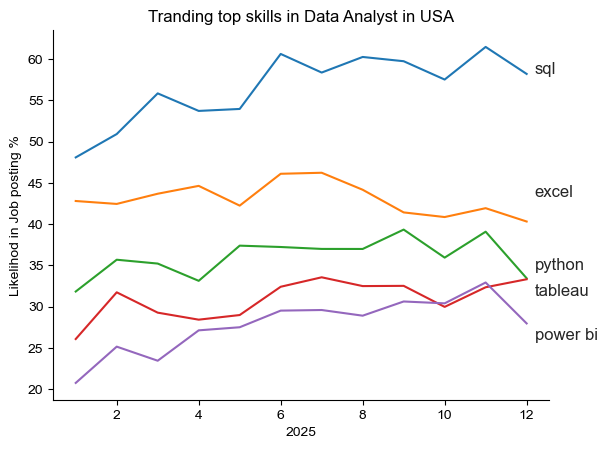

In [10]:
df_plot = df_DA_USA_perc.iloc[:,:5]

sns.lineplot(data=df_plot, dashes=False, palette="tab10")
sns.set_theme(style="ticks")

plt.title("Tranding top skills in Data Analyst in USA")
plt.ylabel("Likelihod in Job posting %")
plt.xlabel(2025)
sns.despine()

plt.legend().remove()


offsets = [0, 3, 1, -2, -2]
for i in range(5):
   plt.text(12.2, df_plot.iloc[-1, i] + offsets[i], df_plot.columns[i])